# Antiferromagnetism in the La$_{2}$CuO$_{4}$ one-band model

In this tutorial, the objective is perform a DMFT calculation in an order phase. Again, we take the example of La$_2$CuO$_4$ which is indeed an antiferromagnet at low temperature. We will use the one-band model derived before, which we repeat is treated as a toy-model and doesn't capture all the important physical components to correctly characterize La$_2$CuO$_4$. For a better model (see [Tutorial 05](05as-la2cuo4.ipynb)). However, by using an artificially large on-site Coulomb repulsion $U$, we can mimic the insulating behavior and the antiferromagnetic state in this toy-model.

Moreover, this example will allow us to introduce:
- The construction of **super lattices** from the DFT extracted tight-binding Hamiltonian, and
- A **non-trivial spin mapping** allowed by the embedding object which enables solving a single impurity problem to capture the physics of both sublattices in the antiferromagnetic state.

## Tight-binding model on the super lattice

The solution we are looking for is antiferromagnetic. In particular, this solutions involves a non-zero symmetry-breaking order parameter, the staggered magnetization defined as
$$ M = \sum_i (-1)^i \langle n_{i\uparrow} - n_{i\downarrow} \rangle $$
where $(-1)^i$ is a phase between in-plane nearest neighbors. In other words, this order parameter breaks the translational invariance of the system, which now has a sublattice $A$ polarized in the $\uparrow$ spin and another sublattice $B$ polarized in the $\downarrow$ spin.

In order to allow DMFT to capture this solution, we need to consider the two sublattices in some way. Moreover, this also means that the unit cell in the ordered phase is doubled compared to the one in the paramagnetic phase.

There are two ways to deal with this:
1) Make a DFT calculation in the supercell and work directly in this space.
2) Use the unit cell DFT calculation along with the Wannier model that we already extract and make a supercell from the tight-binding Hamiltonian.
In this tutorial, we will take the second route to highlight additional features of the TRIQS tight-binding object.


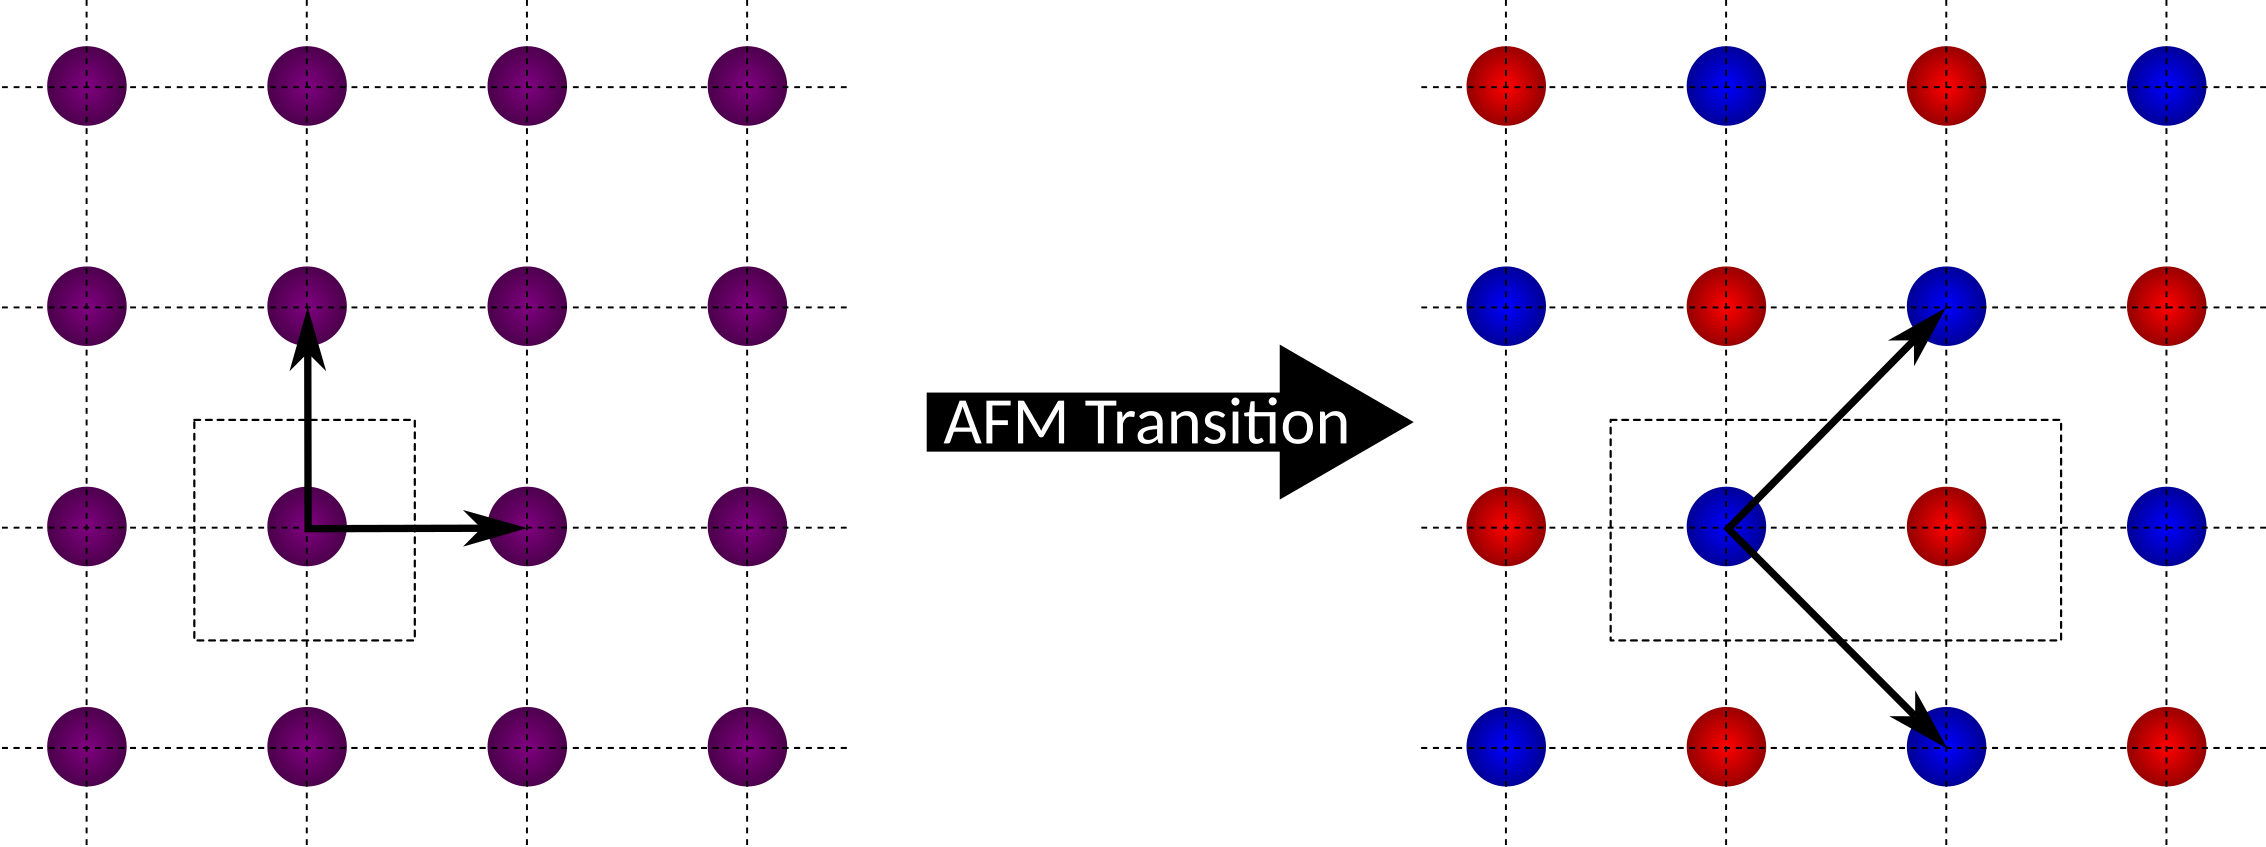

First, load the one-body element corresponding to the one-band model for La$_2$CuO$_4$ used in the [Tutorial 02](02-dmft-lco-1band.ipynb).

In [1]:
import triqs_modest as modest

seedname = 'data/mlwf/lco'
target_density = 2.0 # total number of electrons
spin_kind = "NonPolarized"

shells = [modest.AtomicOrbs(l=2,dim=1,dft_idx=0,cls_idx=0)]
obe = modest.one_body_elements_from_wannier90(seedname, spin_kind, shells)

Starting serial run at: 2025-08-12 18:08:05.669046


In [21]:
!grep -A 3 Lattice 'data/mlwf/lco.wout'

                              Lattice Vectors (Ang)
                    a_1    -1.909145   1.909145   6.603098
                    a_2     1.909145  -1.909145   6.603098
                    a_3     1.909145   1.909145  -6.603098


In [2]:
# super lattice
# Body-centered tetragonal
#   R1 = (-a/2, +a/2, +c/2)
#   R2 = (+a/2, -a/2, +c/2)
#   R3 = (+a/2, +a/2, -c/2)
#  a x = R2 + R3
#  a y = R1 + R3
#  c z = R1 + R2
SL  = modest.Superlattice([( 1, 1, 2), ( 1,-1, 0), ( 1, 0, 0)], 
                          [( 0, 0, 0), ( 0, 1, 1)])
obe_super = modest.fold(SL, obe)

dim_M  = obe_super.C_space.dim

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1
        α:   0   1

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 0, γ = 0, τ = 1)    (imp_idx = 0, γ = 0, τ = 0)  



In [ ]:
E = modest.make_embedding(obe_super.C_space, True).flip_spin([1,2])
print(E.description(True))

In [14]:
import numpy as np 
from triqs.gf import MeshImFreq, MeshDLRImFreq, BlockGf, make_hermitian, inverse
from triqs.operators import n
from triqs.plot.mpl_interface import oplot, plt
from triqs_cthyb import Solver

beta = 10.0     # inverse temperature
n_iw = 251      # number of Matsubara points
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

U = 6.0
h_int = U*n('up_0',0)*n('down_0',0)
solver_params = dict(
                     length_cycle=80, 
                     n_cycles = int(1e+5), n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=15, fit_max_w=20, 
                     imag_threshold = 1e-6,
                     measure_density_matrix = True,
                     use_norm_as_weight =True
                     )

S = Solver(beta = beta, gf_struct = E.imp_block_shape[0], n_iw = n_iw )

Sigma_imp_dynamic, Sigma_imp_static = E.make_zero_imp_self_energies(mesh)[0]

Sigma_imp_static[1] -=  0.5*U - 0.1
Sigma_imp_static[0] -=  0.5*U + 0.1

Ms = []
for n_iter in range(n_dmft_loops := 20):

    Sigma_C_dynamic, Sigma_C_static = E.embed([Sigma_imp_dynamic], [Sigma_imp_static])

    mu = modest.find_chemical_potential(target_density, 
                                        obe_super, 
                                        Sigma_C_dynamic, 
                                        Sigma_C_static, 
                                        modest.BzIntOptions(k_grid=[4,4,4], run_adaptive=False), 
                                        method="bisection",
                                        verbosity=False
                                        )

    hloc0_C =  np.array( [[sigma - mu*np.eye(dim_M) for sigma in site] for site in modest.impurity_levels(obe_super)])
    hloc0 = E.extract(hloc0_C)[0]

    Gloc =  E.extract(modest.gloc(obe_super, mu, Sigma_C_dynamic, Sigma_C_static, modest.BzIntOptions(k_grid=[4,4,4], run_adaptive=False)))[0]
        
    Ms.append((Gloc['up_0'].total_density()-Gloc['down_0'].total_density()).real)
    print(f"n_iter={n_iter} n↑ - n↓ = {Ms[-1]}")

    #Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_static)
    Sigma_imp_iw = Sigma_imp_dynamic.copy()
    for iblock, (block, g) in enumerate(Sigma_imp_iw): Sigma_imp_iw[block] += Sigma_imp_static[iblock]
    G0_iw = inverse(inverse(Gloc) + Sigma_imp_iw)
    S.G0_iw << G0_iw

    # solve!
    S.solve(h_int=h_int, **solver_params)

    Sigma_imp_dynamic = S.Sigma_iw.copy()
    for block, g in Sigma_imp_dynamic: Sigma_imp_dynamic[block] << g - S.Sigma_Hartree[block]
    Sigma_imp_static = list(S.Sigma_Hartree.values())

n_iter=0 n↑ - n↓ = 0.1968430057116733

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
3.08804*c_dag('down_0',0)*c('down_0',0) + 3.08804*c_dag('up_0',0)*c('up_0',0) + 6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
18:17:55 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
18:17:55   2% ETA 00:00:04 cycle 2151 of 100000
18:17:57  50% ETA 00:00:02 cycle 50687 of 100000
18:17:59 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0133612 
Average order                              | 0.00258214
Average sign                               | 0.00277808
Density Matrix for local stati

-1.41938*c_dag('down_0',0)*c('down_0',0) + -1.41938*c_dag('up_0',0)*c('up_0',0) + 6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
18:18:23 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
18:18:23   1% ETA 00:00:06 cycle 1599 of 100000
18:18:25  38% ETA 00:00:03 cycle 38452 of 100000
18:18:28  84% ETA 00:00:00 cycle 84242 of 100000
18:18:29 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0127534 
Average order                              | 0.00256195
Average sign                               | 0.00267701
Density Matrix for local static observable | 0.0754252 
G_tau measure                              | 0.0116362 
Total measure time                       


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.77882*c_dag('down_0',0)*c('down_0',0) + -1.77882*c_dag('up_0',0)*c('up_0',0) + 6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
18:18:34 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
18:18:34   1% ETA 00:00:05 cycle 1952 of 100000
18:18:36  48% ETA 00:00:02 cycle 48052 of 100000
18:18:39 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0127888 
Average order                              | 0.00252541
Average sign                               | 0.00271859
Density Matrix for local static observable | 0.0669275 
G_tau meas

0.9999999999998 instead of 1


�─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.91612*c_dag('down_0',0)*c('down_0',0) + -1.91612*c_dag('up_0',0)*c('up_0',0) + 6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
18:18:43 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
18:18:43   2% ETA 00:00:04 cycle 2152 of 100000
18:18:45  52% ETA 00:00:01 cycle 52938 of 100000
18:18:47 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0123471 
Average order                              | 0.00239203
Average sign                               | 0.00263288
Density Matrix for local static observable | 0.062395  
G_tau measure              

     | 0.00252163
Average sign                               | 0.00263772
Density Matrix for local static observable | 0.0625078 
G_tau measure                              | 0.00826114
Total measure time                         | 0.0882817 
[Rank 0] Acceptance rate for all moves:
Move set Insert two operators: 0.0792988
  Move  Insert Delta_up_0: 0.0789866
  Move  Insert Delta_down_0: 0.0796105
Move set Remove two operators: 0.0793777
  Move  Remove Delta_up_0: 0.0789726
  Move  Remove Delta_down_0: 0.0797832
Move set Insert four operators: 0.0115622
  Move  Insert Delta_up_0_up_0: 0.00881504
  Move  Insert Delta_up_0_down_0: 0.0141689
  Move  Insert Delta_down_0_up_0: 0.0140796
  Move  Insert Delta_down_0_down_0: 0.00918757
Move set Remove four operators: 0.011466
  Move  Remove Delta_up_0_up_0: 0.00865194
  Move  Remove Delta_up_0_down_0: 0.01417
  Move  Remove Delta_down_0_up_0: 0.0140697
  Move  Remove Delta_down_0_down_0: 0.00898013
Move  Shift one operator: 0.097648
[Rank 0] War

Warmup lasted: 0.0463976 seconds [00:00:00]
[Rank 0] Simulation lasted: 4.02285 seconds [00:00:04]
[Rank 0] Number of measures: 100000
Total number of measures: 100000
Average sign: 1
Average order: 1.83778
Auto-correlation time: 0.861264

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.86462*c_dag('down_0',0)*c('down_0',0) + -1.86462*c_dag('up_0',0)*c('up_0',0) + 6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
18:19:08 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
18:19:08   2% ETA 00:00:04 cycle 2163 of 100000
18:19:10  53% ETA 00:00:01 cycle 53394 of 100000
18:19:12 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: n_iter=15 n↑ - n↓ = -0.38137053365410983
Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure   

n_iter=18 n↑ - n↓ = -0.5236531755991708      | 0.00244478
Density Matrix for local static observable | 0.0662473 
G_tau measure                              | 0.0086252 
Total measure time                         | 0.0930096 
[Rank 0] Acceptance rate for all moves:
Move set Insert two operators: 0.0780467
  Move  Insert Delta_up_0: 0.0779384
  Move  Insert Delta_down_0: 0.0781549
Move set Remove two operators: 0.0777271
  Move  Remove Delta_up_0: 0.0777712
  Move  Remove Delta_down_0: 0.077683
Move set Insert four operators: 0.0113284
  Move  Insert Delta_up_0_up_0: 0.00915068
  Move  Insert Delta_up_0_down_0: 0.0133657
  Move  Insert Delta_down_0_up_0: 0.013582
  Move  Insert Delta_down_0_down_0: 0.00920525
Move set Remove four operators: 0.0114365
  Move  Remove Delta_up_0_up_0: 0.00897373
  Move  Remove Delta_up_0_down_0: 0.0138561
  Move  Remove Delta_down_0_up_0: 0.0135132
  Move  Remove Delta_down_0_down_0: 0.00940522
Move  Shift one operator: 0.104142
[Rank 0] Warmup lasted: 0.0

 ...
18:19:30   1% ETA 00:00:04 cycle 1989 of 100000
18:19:32  48% ETA 00:00:02 cycle 48273 of 100000
18:19:34 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.012828  
Average order                              | 0.0029816 
Average sign                               | 0.00239141
Density Matrix for local static observable | 0.0678701 
G_tau measure                              | 0.00890633
Total measure time                         | 0.0949774 
[Rank 0] Acceptance rate for all moves:
Move set Insert two operators: 0.078953
  Move  Insert Delta_up_0: 0.0783459
  Move  Insert Delta_down_0: 0.079559
Move set Remove two operators: 0.0788488
  Move  Remove Delta_up_0: 0.0781889
  Move  Remove Delta_down_0: 0.0795082
Move set Insert four operators: 0.012031
  Move  Insert Delta_up_0_u

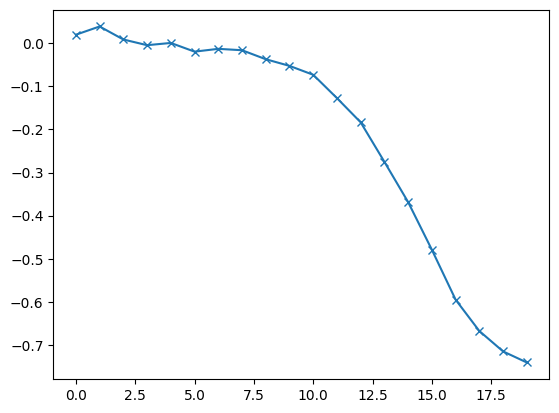

In [11]:
plt.plot(range(len(Ms)), Ms, marker='x')

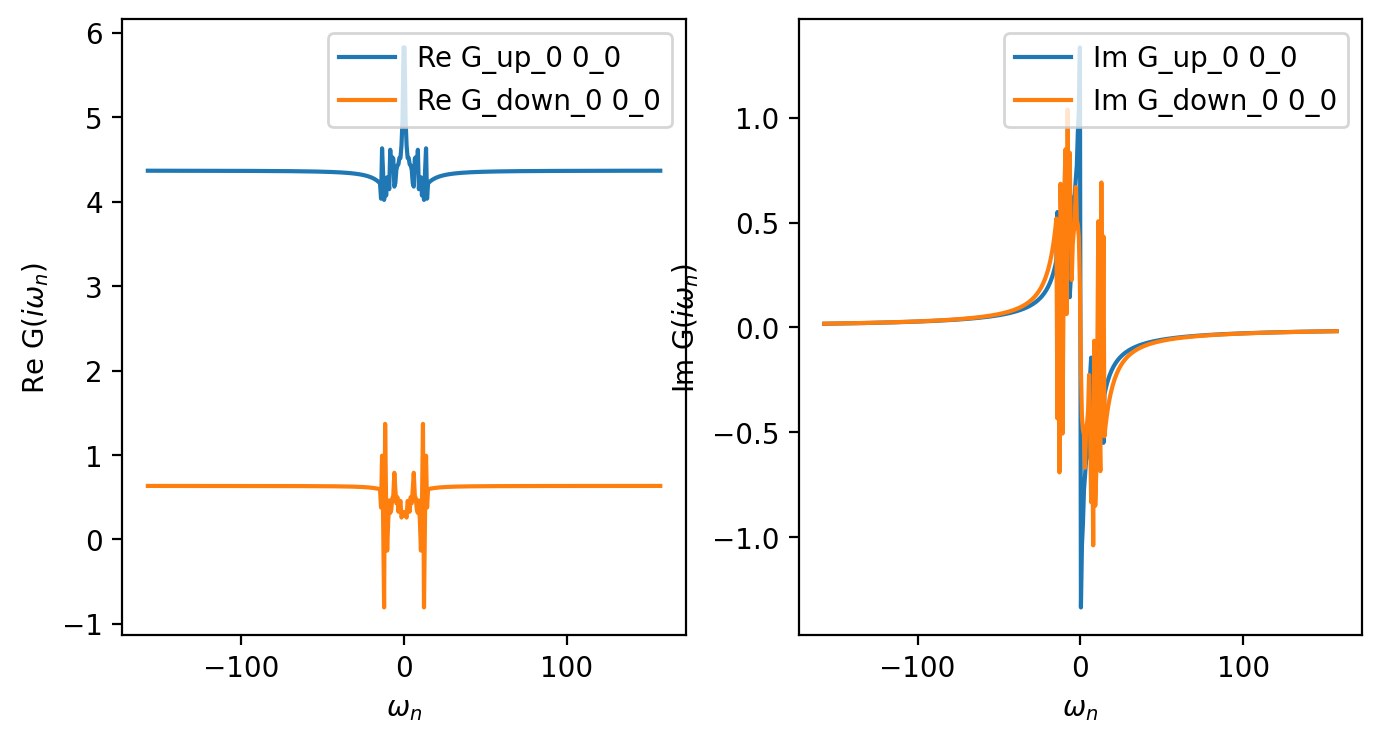

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=200)
ax[0].oplot(S.Sigma_iw.real)
ax[1].oplot(S.Sigma_iw.imag)